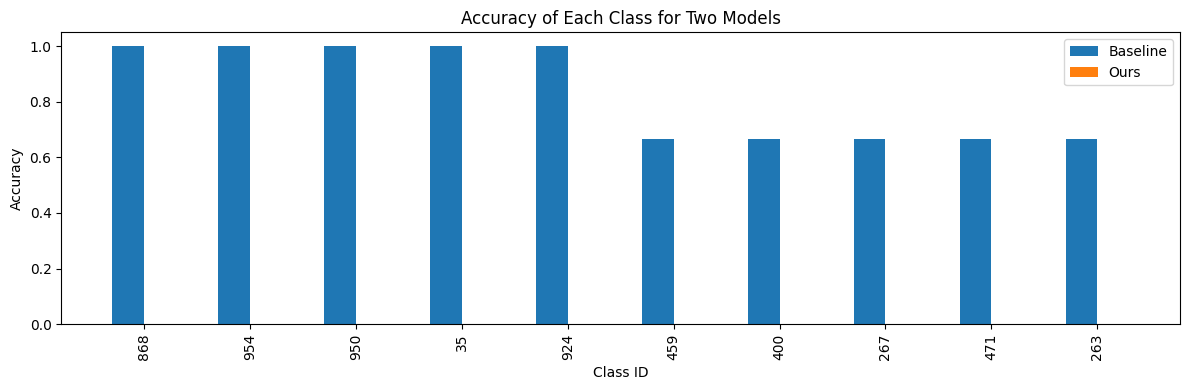

10


In [61]:
import json
import matplotlib.pyplot as plt
import pandas as pd

# Load the JSON data from the two models
file_path_1 = '/home/zhengwei/Desktop/Zhengwei/Projects/CLIP_ReID/logs/visualization_results/marketsketch/class_data.json'
file_path_2 = '/home/zhengwei/Desktop/Zhengwei/Projects/CVAE/outputs/market1k/clipreid_simplevae_tune/novel/2024-07-14/2ndstage_SimpleVAE+2E_128+64z_1e3+3_60+120_KLtotalZ_s2_L1280+CLS_ce+trip+center/visual_results/class_data.json'

with open(file_path_1, 'r') as file:
    data_1 = json.load(file)

with open(file_path_2, 'r') as file:
    data_2 = json.load(file)

q_class_acc_dict_1 = data_1["q_class_acc_dict"]
q_class_path_dict_1 = data_1["q_class_path_dict"]
g_class_path_dict_1 = data_1["g_class_path_dict"]
rank_map_1 = data_1["class_rank1_map_dict"]
# g_class_acc_dict_1 = data_1["g_class_acc_dict"]
# combined_class_acc_dict_1 = {**q_class_acc_dict_1, **g_class_acc_dict_1}

q_class_acc_dict_2 = data_2["q_class_acc_dict"]
q_class_path_dict_2 = data_2["q_class_path_dict"]
g_class_path_dict_2 = data_2["g_class_path_dict"]
rank_map_2 = data_2["class_rank1_map_dict"]
# g_class_acc_dict_2 = data_2["g_class_acc_dict"]
# combined_class_acc_dict_2 = {**q_class_acc_dict_2, **g_class_acc_dict_2}

# Convert dictionaries to DataFrames
df_1 = pd.DataFrame(list(q_class_acc_dict_1.items()), columns=['ClassID', 'Accuracy_1'])
df_2 = pd.DataFrame(list(q_class_acc_dict_2.items()), columns=['ClassID', 'Accuracy_2'])

# Merge DataFrames on ClassID
merged_df = pd.merge(df_1, df_2, on='ClassID')
# Sort by Accuracy_1 for better visualization
merged_df = merged_df.sort_values(by='Accuracy_1', ascending=False)

# Calculate the absolute difference in accuracy
merged_df['Accuracy_Diff'] = (merged_df['Accuracy_1'] - merged_df['Accuracy_2'])

# Define the margin
m = 0.5

# Filter rows where the difference is larger than the margin
filtered_df = merged_df[merged_df['Accuracy_Diff'] > m]
# filtered_df = merged_df

# Display the list of IDs and Accuracy where the difference is larger than the margin
filtered_list = filtered_df[['ClassID', 'Accuracy_1', 'Accuracy_2', 'Accuracy_Diff']].to_dict('records')

# Plot the data with two bins for each class to show the accuracy of each class for the two models
import numpy as np

# Create a DataFrame for the filtered data
filtered_data = pd.DataFrame(filtered_list)

# Plotting the accuracies of each class side by side for the two models
x = np.arange(len(filtered_data['ClassID']))  # the label locations
width = 0.3  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 4))
rects1 = ax.bar(x - width/2, filtered_data['Accuracy_1'], width, label='Baseline')
rects2 = ax.bar(x + width/2, filtered_data['Accuracy_2'], width, label='Ours')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Class ID')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy of Each Class for Two Models')
ax.set_xticks(x)
ax.set_xticklabels(filtered_data['ClassID'],rotation=90)
ax.legend()

fig.tight_layout()

plt.show()
# plt.savefig('class_accuracy_comparison_ours.png')
print(len(filtered_list))
del data_1, data_2


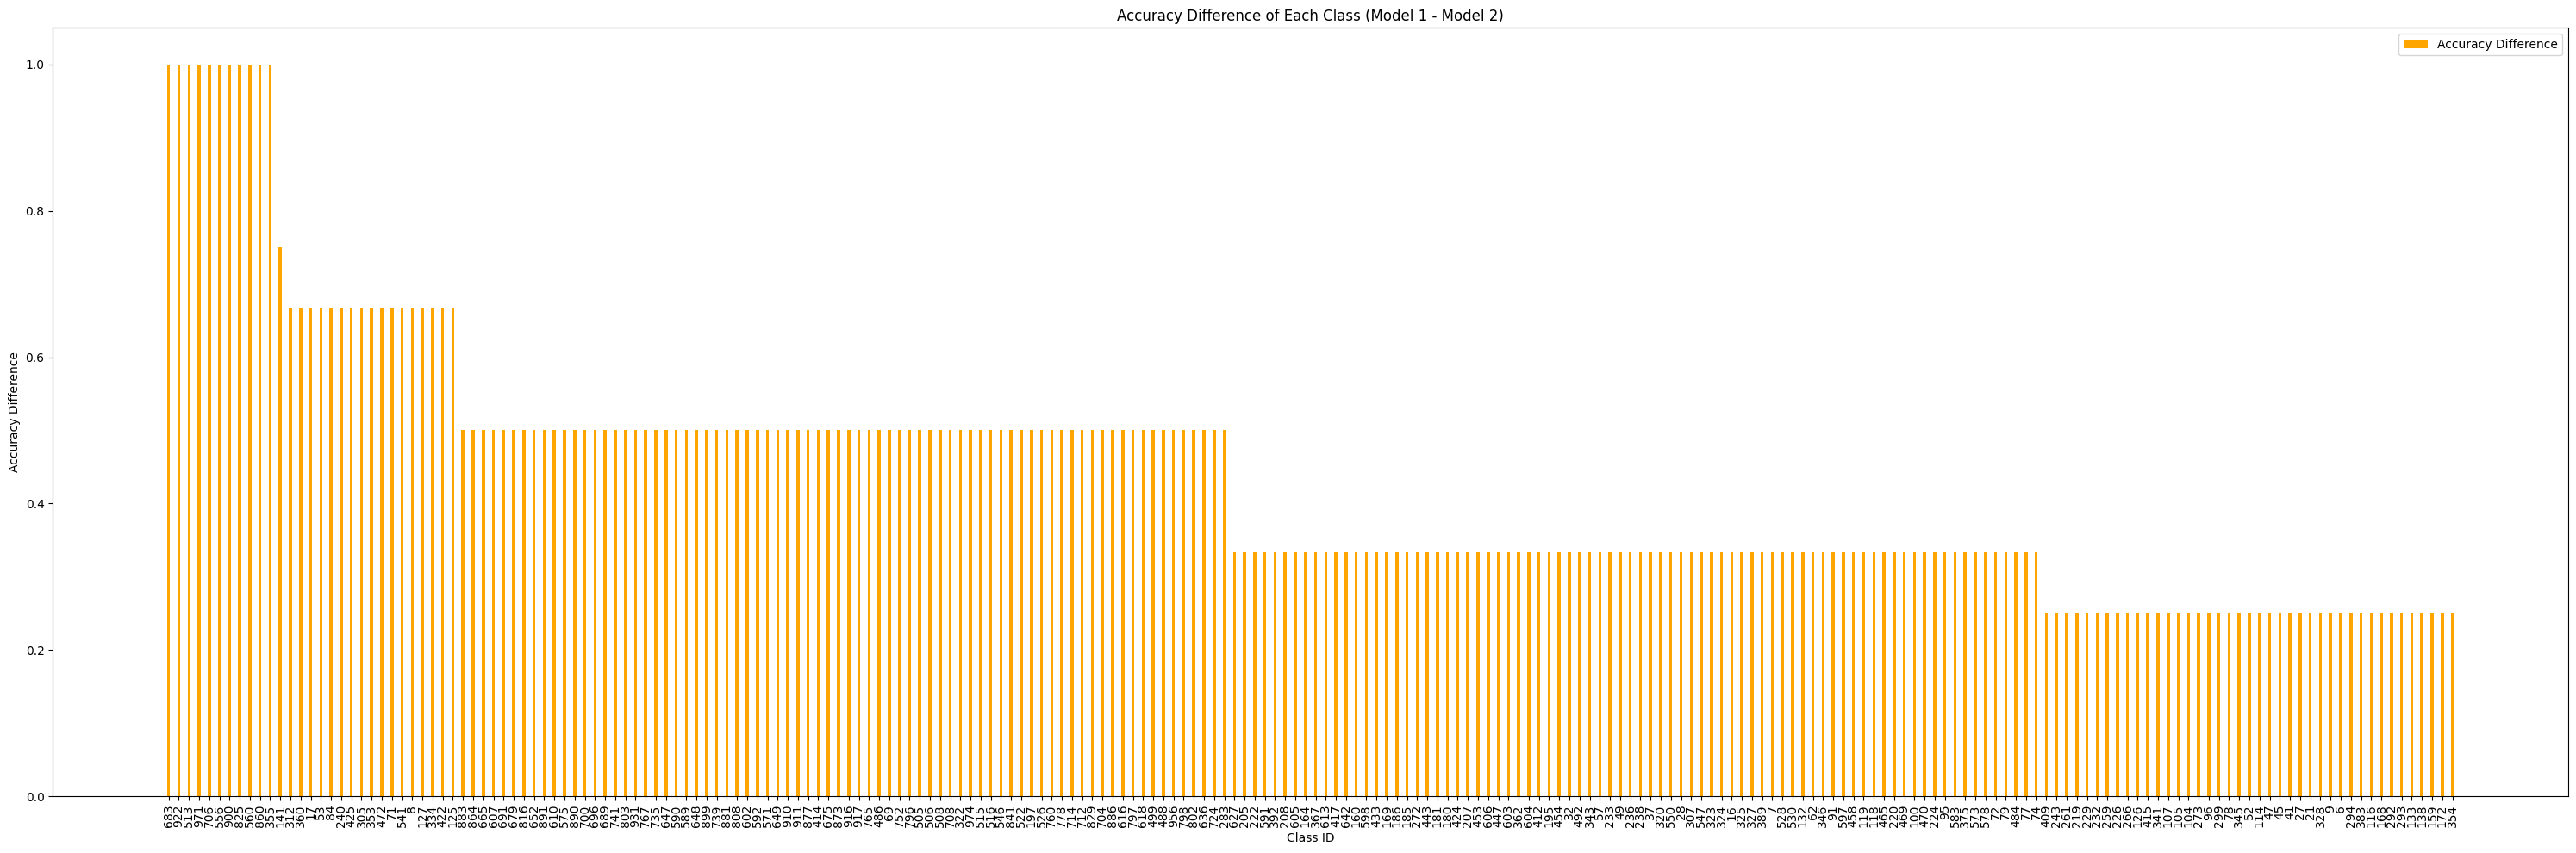

226


In [6]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load the JSON data from the two models
file_path_1 = '/home/zhengwei/Desktop/Zhengwei/Projects/CLIP_ReID/logs/visualization_results/marketsketch/class_data.json'
file_path_2 = '/home/zhengwei/Desktop/Zhengwei/Projects/CVAE/outputs/market1k/clipreid_simplevae_tune/novel/2024-07-14/2ndstage_SimpleVAE+2E_128+64z_1e3+3_60+120_KLtotalZ_s2_L1280+CLS_ce+trip+center/visual_results/class_data.json'

with open(file_path_1, 'r') as file:
    data_1 = json.load(file)

with open(file_path_2, 'r') as file:
    data_2 = json.load(file)

q_class_acc_dict_1 = data_1["q_class_acc_dict"]
q_class_path_dict_1 = data_1["q_class_path_dict"]
g_class_path_dict_1 = data_1["g_class_path_dict"]
rank_map_1 = data_1["class_rank1_map_dict"]

q_class_acc_dict_2 = data_2["q_class_acc_dict"]
q_class_path_dict_2 = data_2["q_class_path_dict"]
g_class_path_dict_2 = data_2["g_class_path_dict"]
rank_map_2 = data_2["class_rank1_map_dict"]

# Convert dictionaries to DataFrames
df_1 = pd.DataFrame(list(q_class_acc_dict_1.items()), columns=['ClassID', 'Accuracy_1'])
df_2 = pd.DataFrame(list(q_class_acc_dict_2.items()), columns=['ClassID', 'Accuracy_2'])

# Merge DataFrames on ClassID
merged_df = pd.merge(df_1, df_2, on='ClassID')

# Calculate the absolute difference in accuracy
merged_df['Accuracy_Diff'] = (merged_df['Accuracy_2'] - merged_df['Accuracy_1'])

# Sort by Accuracy_Diff in descending order
merged_df = merged_df.sort_values(by='Accuracy_Diff', ascending=False)

# Define the margin
m = 0.00

# Filter rows where the difference is larger than the margin
filtered_df = merged_df[merged_df['Accuracy_Diff'] > m]

# Display the list of IDs and Accuracy where the difference is larger than the margin
filtered_list = filtered_df[['ClassID', 'Accuracy_1', 'Accuracy_2', 'Accuracy_Diff']].to_dict('records')

# Create a DataFrame for the filtered data
filtered_data = pd.DataFrame(filtered_list)

# Plotting the accuracy differences
x = np.arange(len(filtered_data['ClassID']))  # the label locations
width = 0.3  # the width of the bars

fig, ax = plt.subplots(figsize=(30, 10))
rects1 = ax.bar(x, filtered_data['Accuracy_Diff'], width, label='Accuracy Difference', color="orange")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Class ID')
ax.set_ylabel('Accuracy Difference')
ax.set_title('Accuracy Difference of Each Class (Model 1 - Model 2)')
ax.set_xticks(x)
ax.set_xticklabels(filtered_data['ClassID'], rotation=90)
ax.legend()

fig.tight_layout()

plt.show()
print(len(filtered_list))
del data_1, data_2


In [58]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches
import os.path as osp
from PIL import Image, ImageOps
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
def add_border(img, color, border_size=5):
    """Add a border to the image with the specified color and size."""
    return ImageOps.expand(img, border=border_size, fill=color)

def display_images_for_ids(filtered_list, q_class_path_dict_1, g_class_path_dict_1, rank_map_base, rank_map_ours):
    with PdfPages("visualization_base.pdf") as pdf:
        for item in filtered_list:
            class_id = item['ClassID']
            q_img_paths = q_class_path_dict_1.get(class_id, [])
            g_img_paths = g_class_path_dict_1.get(class_id, [])
            # print(rank_map_base[class_id])
            img_paths = q_img_paths + g_img_paths
            query_len = len(q_img_paths)
            gallery_len = len(g_img_paths)
            # img_titles = [f'Class {class_id} - Query', f'Class {class_id} - Gallery']
            plt.figure(figsize=(13, 4))
            print(img_paths)
            for i, img_path in enumerate(img_paths):
                if img_path is not None:
                    # file_name_modified = osp.basename(img_path[0])[:-3]+".jpg"
                    file_name_modified = osp.basename(img_path[0])
                    if i < query_len:
                        img = Image.open(osp.join(sketch_path, file_name_modified)).convert('RGB')
                    else:
                        img = Image.open(osp.join(rgb_path, file_name_modified)).convert('RGB')
                    # Resize the image
                    img = img.resize((128,256))
                    
                    color = 'green' if img_path[1] else 'red'
                    img = add_border(img, color, border_size=2)
                    # Convert image to array
                    img = np.array(img)
                    plt.subplot(1, query_len + gallery_len, i + 1)
                    plt.imshow(img)
                    plt.title("{}".format(file_name_modified[:7]))
                    plt.axis('off')
                    
                    # # Add colored margin
                    # ax = plt.gca()
                    # ax.set_aspect('equal')
                    # color = 'green' if img_path[1] else 'red'
                    # rect = patches.Rectangle((0, 0), img.shape[1], img.shape[0], linewidth=5, edgecolor=color, facecolor='none')
                    # ax.add_patch(rect)
              # Set a general title
            if rank_map_base[class_id]['rank1'] > rank_map_ours[class_id]['rank1']:
                plt.suptitle("$\mathbf{{Base\ R@1/mAP-{:.2f}/{:.2f}}}$ \n Ours R@1/mAP-{:.2f}/{:.2f}".format(
                    rank_map_base[class_id]['rank1'], rank_map_base[class_id]['mAP'],
                    rank_map_ours[class_id]['rank1'], rank_map_ours[class_id]['mAP']), y=1.0)
            else:
                plt.suptitle("Base R@1/mAP-{:.2f}/{:.2f} \n $\mathbf{{Ours\ R@1/mAP-{:.2f}/{:.2f}}}$".format(
                    rank_map_base[class_id]['rank1'], rank_map_base[class_id]['mAP'],
                    rank_map_ours[class_id]['rank1'], rank_map_ours[class_id]['mAP']), y=1.0)
            
            plt.tight_layout() # Adjust the layout
            plt.subplots_adjust(top=0.85)
            pdf.savefig()  # Save the current figure into the PDF
            plt.close()
            # plt.show()
            # break


rgb_path = '/home/zhengwei/Desktop/Zhengwei/Projects/datasets/Market-Sketch-1K/photo/all'
sketch_path = '/home/zhengwei/Desktop/Zhengwei/Projects/datasets/Market-Sketch-1K/sketch/fewshot/2sketch/test'
display_images_for_ids(filtered_list, q_class_path_dict_1, g_class_path_dict_1, rank_map_1, rank_map_2)

[['0036_A.jpg', True], ['0036_E.jpg', True], ['0036_F.jpg', True], ['0036_c2s1_002551_00.jpg', True], ['0036_c6s1_003451_00.jpg', True]]
[['0264_C.jpg', True], ['0264_D.jpg', False], ['0264_E.jpg', True], ['0264_c1s1_056006_02.jpg', True], ['0264_c1s1_061881_01.jpg', True]]
[['0268_A.jpg', True], ['0268_C.jpg', True], ['0268_F.jpg', False], ['0268_c4s1_057057_02.jpg', True], ['0268_c5s1_068248_01.jpg', True]]
[['0403_A.jpg', False], ['0403_C.jpg', True], ['0403_E.jpg', True], ['0403_c2s1_096496_05.jpg', True], ['0403_c3s1_096692_02.jpg', True]]
[['0462_A.jpg', True], ['0462_E.jpg', False], ['0462_F.jpg', True], ['0462_c1s2_045246_00.jpg', True], ['0462_c2s1_117466_00.jpg', True]]
[['0474_A.jpg', True], ['0474_B.jpg', False], ['0474_F.jpg', True], ['0474_c3s1_122333_00.jpg', True], ['0474_c5s1_122770_00.jpg', True]]
[['0874_C.jpg', True], ['0874_E.jpg', True], ['0874_c2s3_063652_00.jpg', True], ['0874_c3s3_070019_00.jpg', True]]
[['0931_A.jpg', True], ['0931_E.jpg', True], ['0931_c2s2_1

### Process the retrievaled images according to the difference list

In [39]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches
import os.path as osp
from PIL import Image, ImageOps
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
import json
from matplotlib.gridspec import GridSpec

rgb_path = '/home/zhengwei/Desktop/Zhengwei/Projects/datasets/Market-Sketch-1K/photo/all'
sketch_path = '/home/zhengwei/Desktop/Zhengwei/Projects/datasets/Market-Sketch-1K/sketch/fewshot/2sketch/test'

def add_border(img, color, border_size=5):
    """Add a border to the image with the specified color and size."""
    return ImageOps.expand(img, border=border_size, fill=color)

def display_images_with_retrieval(filtered_list, rank_results_1, rank_results_2, target_size=(128, 256), pdf_path='ranked_base.pdf'):
    with PdfPages(pdf_path) as pdf:
        for item in filtered_list:
            class_label = item['ClassID']

            # Find all entries in rank_results that match the class label
            matching_entries_1 = [entry for entry in rank_results_1 if int(float(rank_results_1[entry]['label'])) == int(class_label)]
            matching_entries_2 = [entry for entry in rank_results_2 if int(float(rank_results_2[entry]['label'])) == int(class_label)]
            
            # print(matching_entries_1)
            # print(matching_entries_2)
            
            for entry_1, entry_2 in zip(matching_entries_1, matching_entries_2):

                query_info_1 = rank_results_1[str(entry_1)]
                query_img_path = query_info_1['img_name']
                retrieval_img_names_1 = query_info_1['rank_names'][:10]
                retrieval_labels_1 = query_info_1['rank_label'][:10]
                query_label_1 = query_info_1['label']
                
                query_info_2 = rank_results_2[str(entry_2)]
                retrieval_img_names_2 = query_info_2['rank_names'][:10]
                retrieval_labels_2 = query_info_2['rank_label'][:10]
                query_label_2 = query_info_2['label']
            
                if 'home' in query_img_path:
                    query_img_path = osp.basename(query_img_path).replace('pt', 'jpg')
                if 'home' in retrieval_img_names_1[0]:
                    retrieval_img_names_1 = [osp.basename(img_path).replace('pt', 'jpg') for img_path in retrieval_img_names_1]
                if 'home' in retrieval_img_names_2[0]:
                    retrieval_img_names_2 = [osp.basename(img_path).replace('pt', 'jpg') for img_path in retrieval_img_names_2]
            
                plt.figure(figsize=(15, 6.5))
                gs = GridSpec(2, 11, hspace=0.01, wspace=0.05)
                
                # Load and display the query image
                query_img = Image.open(osp.join(sketch_path, query_img_path)).convert('RGB')
                query_img = query_img.resize(target_size)
                query_img = add_border(query_img, 'blue')
                query_img = np.array(query_img)
                
                ax = plt.subplot(gs[0, 0])
                ax.imshow(query_img)
                ax.set_title(f'Base {query_img_path[:-4]}')
                ax.axis('off')
                
                ax = plt.subplot(gs[1, 0])
                ax.imshow(query_img)
                ax.set_title(f'Ours {query_img_path[:-4]}')
                ax.axis('off')

                # Load and display the retrieval images from model 1
                for i, (retrieval_img_name, retrieval_label) in enumerate(zip(retrieval_img_names_1, retrieval_labels_1)):
                    retrieval_img = Image.open(osp.join(rgb_path, retrieval_img_name)).convert('RGB')
                    retrieval_img = retrieval_img.resize(target_size)
                    color = 'green' if retrieval_label == query_label_1 else 'red'
                    retrieval_img = add_border(retrieval_img, color)
                    retrieval_img = np.array(retrieval_img)
                    
                    ax = plt.subplot(gs[0, i + 1])
                    ax.imshow(retrieval_img)
                    ax.set_title(retrieval_img_name[:6])
                    ax.axis('off')
                
                # Load and display the retrieval images from model 2
                for i, (retrieval_img_name, retrieval_label) in enumerate(zip(retrieval_img_names_2, retrieval_labels_2)):
                    retrieval_img = Image.open(osp.join(rgb_path, retrieval_img_name)).convert('RGB')
                    retrieval_img = retrieval_img.resize(target_size)
                    color = 'green' if retrieval_label == query_label_2 else 'red'
                    retrieval_img = add_border(retrieval_img, color)
                    retrieval_img = np.array(retrieval_img)
                    
                    ax = plt.subplot(gs[1, i + 1])
                    ax.imshow(retrieval_img)
                    ax.set_title(retrieval_img_name[:6])
                    ax.axis('off')
                
                plt.tight_layout() # Adjust the layout
                # plt.subplots_adjust(top=0.85)
                pdf.savefig()  # Save the current figure into the PDF
                plt.close()
                # plt.show()
                # break
            # break
ours_json_path = '/home/zhengwei/Desktop/Zhengwei/Projects/CVAE/outputs/market1k/clipreid_simplevae_tune/novel/2024-07-14/2ndstage_SimpleVAE+2E_128+64z_1e3+3_60+120_KLtotalZ_s2_L1280+CLS_ce+trip+center/visual_results/rank_results.json'
baseline_json_path = '/home/zhengwei/Desktop/Zhengwei/Projects/CLIP_ReID/logs/visualization_results/marketsketch/rank_results.json'
# Load rank results from JSON
with open(baseline_json_path, 'r') as file:
    rank_results_1 = json.load(file)

with open(ours_json_path, 'r') as file:
    rank_results_2 = json.load(file)

display_images_with_retrieval(filtered_list, rank_results_1, rank_results_2)
print("Done")

/tmp/ipykernel_3600390/7006132.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout() # Adjust the layout


Done


In [23]:
print(filtered_list)

[{'ClassID': '35', 'Accuracy_1': 1.0, 'Accuracy_2': 0.0, 'Accuracy_Diff': 1.0}, {'ClassID': '263', 'Accuracy_1': 0.6666666666666666, 'Accuracy_2': 0.0, 'Accuracy_Diff': 0.6666666666666666}, {'ClassID': '267', 'Accuracy_1': 0.6666666666666666, 'Accuracy_2': 0.0, 'Accuracy_Diff': 0.6666666666666666}, {'ClassID': '400', 'Accuracy_1': 0.6666666666666666, 'Accuracy_2': 0.0, 'Accuracy_Diff': 0.6666666666666666}, {'ClassID': '459', 'Accuracy_1': 0.6666666666666666, 'Accuracy_2': 0.0, 'Accuracy_Diff': 0.6666666666666666}, {'ClassID': '471', 'Accuracy_1': 0.6666666666666666, 'Accuracy_2': 0.0, 'Accuracy_Diff': 0.6666666666666666}, {'ClassID': '868', 'Accuracy_1': 1.0, 'Accuracy_2': 0.0, 'Accuracy_Diff': 1.0}, {'ClassID': '924', 'Accuracy_1': 1.0, 'Accuracy_2': 0.0, 'Accuracy_Diff': 1.0}, {'ClassID': '950', 'Accuracy_1': 1.0, 'Accuracy_2': 0.0, 'Accuracy_Diff': 1.0}, {'ClassID': '954', 'Accuracy_1': 1.0, 'Accuracy_2': 0.0, 'Accuracy_Diff': 1.0}]


In [87]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.io import loadmat
import os.path as osp

mat_base_path = '/home/zhengwei/Desktop/Zhengwei/Projects/CLIP_ReID/logs/visualization_results/marketsketch/pytorch_result.mat'
mat_novel_path = '/home/zhengwei/Desktop/Zhengwei/Projects/CVAE/outputs/market1k/clipreid_simplevae_tune/novel/2024-07-14/2ndstage_SimpleVAE+2E_128+64z_1e3+3_60+120_KLtotalZ_s2_L1280+CLS_ce+trip+center/visual_results/pytorch_result.mat'

base_mat = loadmat(mat_base_path)
novel_mat = loadmat(mat_novel_path)
# result = {'gallery_f':gf,'gallery_label':g_pids,'gallery_cam':g_camids, 'gallery_name': g_all_img_path ,'query_f':qf,'query_label':q_pids,'query_cam':q_camids, 'query_name': q_all_img_path}
base_q_features = base_mat['query_f']
base_g_features = base_mat['gallery_f']
base_q_labels = base_mat['query_label'].squeeze()
base_g_labels = base_mat['gallery_label'].squeeze()
base_q_path = base_mat['query_name']
base_g_path = base_mat['gallery_name']

novel_q_features = novel_mat['query_f']
novel_g_features = novel_mat['gallery_f']
novel_q_labels = novel_mat['query_label'].squeeze()
novel_g_labels = novel_mat['gallery_label'].squeeze()
novel_q_path = novel_mat['query_name']
novel_g_path = novel_mat['gallery_name']

print(base_g_labels[:10])
print(novel_g_labels[:10])


# Calculate the cosine similarity between the query and gallery features



[0. 0. 1. 1. 2. 2. 3. 3. 4. 4.]
[0. 0. 1. 1. 2. 2. 3. 3. 4. 4.]


In [40]:
print(base_q_path[-10:])
# find index have content of "0563" in the base_q_path
index = []
for i in range(len(base_q_path)):
    if "0563" in base_q_path[i]:
        index.append(i)
print(index)

print(base_g_labels[index])
print(base_q_path[:4])

['1044_E.jpg' '1044_F.jpg' '1046_C.jpg' '1046_E.jpg' '1047_C.jpg'
 '1047_F.jpg' '1050_C.jpg' '1050_F.jpg' '1053_C.jpg' '1053_F.jpg']
[1810, 1811]
[901. 901.]
['0001_C.jpg' '0001_E.jpg' '0001_F.jpg' '0002_A.jpg']


Selected IDs: [541. 541. 541.] with file: ['0544_C.jpg' '0544_D.jpg' '0544_F.jpg']
[1764, 1765, 1766] ['0544_C.jpg', '0544_D.jpg', '0544_F.jpg']
[1088, 1089, 273, 907, 51, 1562, 1563, 384, 1087, 1530, 1086, 184, 908, 598, 599, 246, 1405, 182, 1542]


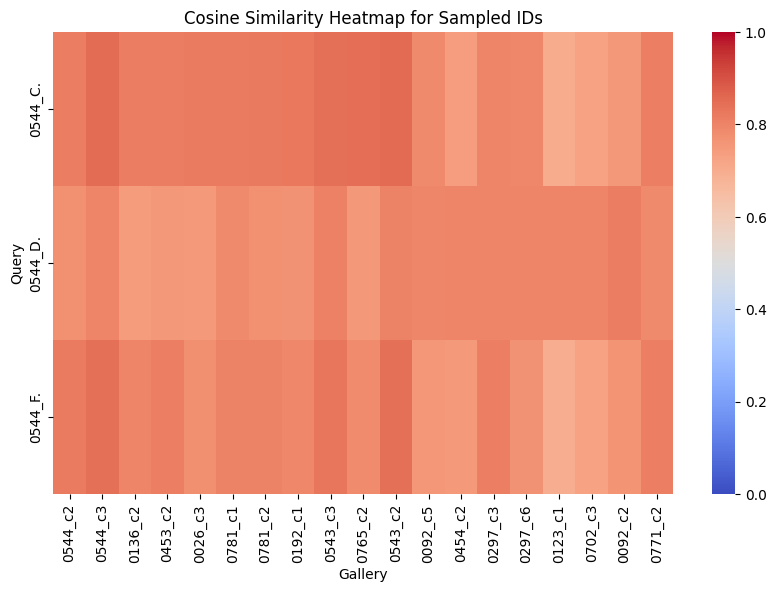

In [90]:
# nolmalize the features
base_q_features = base_q_features / np.linalg.norm(base_q_features, axis=1, keepdims=True)
base_g_features = base_g_features / np.linalg.norm(base_g_features, axis=1, keepdims=True)

target_name = '0544'
# Randomly sample 10 unique IDs from the available IDs in base query labels
unique_ids = np.unique(base_q_labels)
# sampled_ids = np.random.choice(unique_ids, 2, replace=False)
index = []
for i in range(len(base_q_path)):
    if target_name in base_q_path[i]:
        index.append(i)

sampled_ids = base_q_labels[index]

print("Selected IDs:", sampled_ids, "with file:", base_q_path[index])

# Prepare a subset of the data for visualization based on the sampled IDs
selected_query_indices = index
selected_query_features = base_q_features[selected_query_indices]
selected_query_labels = base_q_labels[selected_query_indices]
selected_query_names = [base_q_path[i] for i in selected_query_indices]

print(selected_query_indices, selected_query_names)

# Prepare gallery indices for the sampled IDs and find the highest similarity samples
selected_gallery_indices = []
highest_similarity_indices = []

for q_idx, q_label in zip(selected_query_indices, selected_query_labels):
    same_id_gallery_indices = [i for i, label in enumerate(base_g_labels) if int(label) == int(q_label)]
    same_id_gallery_features = base_g_features[same_id_gallery_indices]
    
    # Compute similarity with the current query
    similarities = 1 - cdist([base_q_features[q_idx]], base_g_features, metric='cosine').flatten()
    
    # Find the indices of the top 5 highest similarity gallery samples
    top_5_sim_indices = np.argsort(similarities)[-10:]
    # Find the gallery index with the highest similarity
    # highest_sim_idx = same_id_gallery_indices[np.argmax(similarities)]
    
    # Add indices to lists
    selected_gallery_indices.extend(same_id_gallery_indices)
    highest_similarity_indices.extend(top_5_sim_indices)


# Remove duplicates and maintain order
highest_similarity_indices = list(dict.fromkeys(highest_similarity_indices))
selected_gallery_indices = list(dict.fromkeys(selected_gallery_indices + highest_similarity_indices))  # Combine while maintaining order

print(selected_gallery_indices)

# Extract selected gallery features and labels
selected_gallery_features = base_g_features[selected_gallery_indices]
selected_gallery_labels = base_g_labels[selected_gallery_indices]
selected_gallery_names = [base_g_path[i] for i in selected_gallery_indices]


# Compute the cosine similarity matrix
similarity_matrix = 1 - cdist(selected_query_features, selected_gallery_features, metric='cosine')

# Create labels for heatmap visualization
# query_heatmap_labels = [f'Q{label}_{i}' for i, label in enumerate(selected_query_labels)]
# gallery_heatmap_labels = [f'G{label}_{i}' for i, label in enumerate(selected_gallery_labels)]
query_heatmap_labels = [f'{name[:7]}' for name in selected_query_names]
gallery_heatmap_labels = [f'{name[:7]}' for name in selected_gallery_names]

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(similarity_matrix, annot=False, fmt=".2f", cmap="coolwarm", vmax=1, vmin=0,
            xticklabels=gallery_heatmap_labels, yticklabels=query_heatmap_labels)
plt.xlabel('Gallery')
plt.ylabel('Query')
plt.title('Cosine Similarity Heatmap for Sampled IDs')
plt.show()

Selected query indices: [1764, 1765, 1766]
Selected query names: ['/home/zhengwei/Desktop/Zhengwei/Projects/datasets/Market-Sketch-1K/tensor/CLIPreidFinetune/sketch/fewshot/2sketch/test/0544_C.pt', '/home/zhengwei/Desktop/Zhengwei/Projects/datasets/Market-Sketch-1K/tensor/CLIPreidFinetune/sketch/fewshot/2sketch/test/0544_D.pt', '/home/zhengwei/Desktop/Zhengwei/Projects/datasets/Market-Sketch-1K/tensor/CLIPreidFinetune/sketch/fewshot/2sketch/test/0544_F.pt']


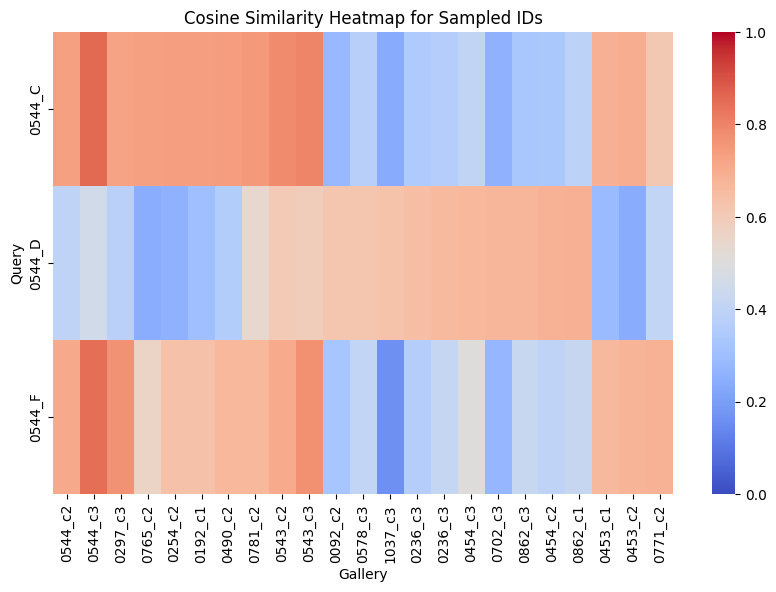

In [92]:

# Normalize the features
novel_q_features = novel_q_features / np.linalg.norm(novel_q_features, axis=1, keepdims=True)
novel_g_features = novel_g_features / np.linalg.norm(novel_g_features, axis=1, keepdims=True)

# Select query samples based on the specified condition
index = []
for i in range(len(novel_q_path)):
    if target_name in novel_q_path[i]:
        index.append(i)

selected_query_indices = index
selected_query_features = novel_q_features[selected_query_indices]
selected_query_labels = novel_q_labels[selected_query_indices]
selected_query_names = [novel_q_path[i] for i in selected_query_indices]

print("Selected query indices:", selected_query_indices)
print("Selected query names:", selected_query_names)

# Prepare gallery indices for the sampled IDs and find the highest similarity samples
selected_gallery_indices = []
highest_similarity_indices = []

for q_idx, q_label in zip(selected_query_indices, selected_query_labels):
    same_id_gallery_indices = [i for i, label in enumerate(novel_g_labels) if int(label) == int(q_label)]
    same_id_gallery_features = novel_g_features[same_id_gallery_indices]
    
    # Compute similarity with the current query
    similarities = 1 - cdist([novel_q_features[q_idx]], novel_g_features, metric='cosine').flatten()
    
    # Find the indices of the top 5 highest similarity gallery samples
    top_5_sim_indices = np.argsort(similarities)[-10:]
    
    # Add indices to lists
    selected_gallery_indices.extend(same_id_gallery_indices)
    highest_similarity_indices.extend(top_5_sim_indices)

# Remove duplicates and maintain order
highest_similarity_indices = list(dict.fromkeys(highest_similarity_indices))
selected_gallery_indices = list(dict.fromkeys(selected_gallery_indices + highest_similarity_indices))  # Combine while maintaining order

# Extract selected gallery features and labels
selected_gallery_features = novel_g_features[selected_gallery_indices]
selected_gallery_labels = novel_g_labels[selected_gallery_indices]
selected_gallery_names = [novel_g_path[i] for i in selected_gallery_indices]

# Compute the cosine similarity matrix
similarity_matrix = 1 - cdist(selected_query_features, selected_gallery_features, metric='cosine')

# Create labels for heatmap visualization
query_heatmap_labels = [f'{osp.basename(name)[:6]}' for name in selected_query_names]
gallery_heatmap_labels = [f'{osp.basename(name)[:7]}' for name in selected_gallery_names]

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(similarity_matrix, annot=False, fmt=".2f", cmap="coolwarm", vmax=1, vmin=0,
            xticklabels=gallery_heatmap_labels, yticklabels=query_heatmap_labels)
plt.xlabel('Gallery')
plt.ylabel('Query')
plt.title('Cosine Similarity Heatmap for Sampled IDs')
plt.show()

In [1]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import random
import numpy as np

# Load the JSON data from the two models
file_path_1 = '/home/zhengwei/Desktop/Zhengwei/Projects/CLIP_ReID/logs/visualization_results/marketsketch/class_data.json'
file_path_2 = '/home/zhengwei/Desktop/Zhengwei/Projects/CVAE/outputs/market1k/clipreid_simplevae_tune/novel/2024-07-14/2ndstage_SimpleVAE+2E_128+64z_1e3+3_60+120_KLtotalZ_s2_L1280+CLS_ce+trip+center/visual_results/class_data.json'

with open(file_path_1, 'r') as file:
    data_1 = json.load(file)

with open(file_path_2, 'r') as file:
    data_2 = json.load(file)

q_class_acc_dict_1 = data_1["q_class_acc_dict"]
q_class_path_dict_1 = data_1["q_class_path_dict"]
g_class_path_dict_1 = data_1["g_class_path_dict"]
rank_map_1 = data_1["class_rank1_map_dict"]
# g_class_acc_dict_1 = data_1["g_class_acc_dict"]
# combined_class_acc_dict_1 = {**q_class_acc_dict_1, **g_class_acc_dict_1}

q_class_acc_dict_2 = data_2["q_class_acc_dict"]
q_class_path_dict_2 = data_2["q_class_path_dict"]
g_class_path_dict_2 = data_2["g_class_path_dict"]
rank_map_2 = data_2["class_rank1_map_dict"]
# g_class_acc_dict_2 = data_2["g_class_acc_dict"]
# combined_class_acc_dict_2 = {**q_class_acc_dict_2, **g_class_acc_dict_2}

# Convert dictionaries to DataFrames
df_1 = pd.DataFrame(list(q_class_acc_dict_1.items()), columns=['ClassID', 'Accuracy_1'])
df_2 = pd.DataFrame(list(q_class_acc_dict_2.items()), columns=['ClassID', 'Accuracy_2'])

# Merge DataFrames on ClassID
merged_df = pd.merge(df_1, df_2, on='ClassID')

# Add rank1 and mAP columns
merged_df['Rank1_1'] = merged_df['ClassID'].map(lambda x: rank_map_1.get(x, {}).get('rank1', None))
merged_df['mAP_1'] = merged_df['ClassID'].map(lambda x: rank_map_1.get(x, {}).get('mAP', None))
merged_df['Rank1_2'] = merged_df['ClassID'].map(lambda x: rank_map_2.get(x, {}).get('rank1', None))
merged_df['mAP_2'] = merged_df['ClassID'].map(lambda x: rank_map_2.get(x, {}).get('mAP', None))

# Sort by Accuracy_1 for better visualization
# merged_df = merged_df.sort_values(by='Accuracy_1', ascending=False)

# Filter the DataFrame based on the specified conditions
name_1 = "Accuracy_1"
name_2 = "Accuracy_2"

condition_1 = merged_df[(merged_df[name_1] == 1) & (merged_df[name_2] == 1)]
condition_2 = merged_df[(merged_df[name_1] >= 0.5) & (merged_df[name_2] == 0 )]
condition_3 = merged_df[(merged_df[name_1] == 0) & (merged_df[name_2] >= 0.5)]
condition_4 = merged_df[(merged_df[name_1] == 0 ) & (merged_df[name_2] == 0 )]

# Extract filtered lists
filtered_list_1 = condition_1.to_dict('records')
filtered_list_2 = condition_2.to_dict('records')
filtered_list_3 = condition_3.to_dict('records')
filtered_list_4 = condition_4.to_dict('records')

# Display the filtered lists
print("Condition 1 (json1 ACC == 1 and json2 ACC == 1):", len(filtered_list_1))
print("Condition 2 (json1 ACC >= 0.5 and json2 ACC == 0):", len(filtered_list_2))
print("Condition 3 (json1 ACC == 0 and json2 ACC >= 0.5):", len(filtered_list_3))
print("Condition 4 (json1 ACC == 0 and json2 ACC == 0):", len(filtered_list_4))

# plt.savefig('class_accuracy_comparison_ours.png')
print(filtered_list_2[:2])
del df_1, df_2

import numpy as np
from scipy.io import loadmat

# Load the .mat files
mat_file_path_1 = '/home/zhengwei/Desktop/Zhengwei/Projects/CLIP_ReID/logs/visualization_results/marketsketch/pytorch_result.mat'
mat_file_path_2 = '/home/zhengwei/Desktop/Zhengwei/Projects/CVAE/outputs/market1k/clipreid_simplevae_tune/novel/2024-07-14/2ndstage_SimpleVAE+2E_128+64z_1e3+3_60+120_KLtotalZ_s2_L1280+CLS_ce+trip+center/visual_results/pytorch_result.mat'

mat_1 = loadmat(mat_file_path_1)
mat_2 = loadmat(mat_file_path_2)

# Extract features and labels
query_features_1 = mat_1['query_f']
gallery_features_1 = mat_1['gallery_f']
query_features_1 = query_features_1 / np.linalg.norm(query_features_1, axis=1, keepdims=True)
gallery_features_1 = gallery_features_1 / np.linalg.norm(gallery_features_1, axis=1, keepdims=True)
query_labels_1 = mat_1['query_label'].squeeze()
query_labels_1 = query_labels_1.astype(int).astype(str)
gallery_labels_1 = mat_1['gallery_label'].squeeze()
gallery_labels_1 = gallery_labels_1.astype(int).astype(str)

query_features_2 = mat_2['query_f']
gallery_features_2 = mat_2['gallery_f']
query_features_2 = query_features_2 / np.linalg.norm(query_features_2, axis=1, keepdims=True)
gallery_features_2 = gallery_features_2 / np.linalg.norm(gallery_features_2, axis=1, keepdims=True)
query_labels_2 = mat_2['query_label'].squeeze()
query_labels_2 = query_labels_2.astype(int).astype(str)
gallery_labels_2 = mat_2['gallery_label'].squeeze()
gallery_labels_2 = gallery_labels_2.astype(int).astype(str)

# Create feature and label lists based on the filtered lists
def create_feature_label_lists(filtered_list, query_features, gallery_features, query_labels, gallery_labels, seed=None):
    
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    
    feature_list = []
    label_list = []
    
    # Randomly select 50 items from the filtered_list
    random_selected_items = random.sample(filtered_list, min(50, len(filtered_list)))
    
    for item in (random_selected_items):
        class_id = item['ClassID']
        query_indices = np.where(query_labels == class_id)[0]
        gallery_indices = np.where(gallery_labels == class_id)[0]
        query_features_list = query_features[query_indices]
        gallery_features_list = gallery_features[gallery_indices]
        query_labels_list = query_labels[query_indices]
        gallery_labels_list = gallery_labels[gallery_indices]
        feature_list.extend(query_features_list)
        feature_list.extend(gallery_features_list)
        label_list.extend(query_labels_list)
        label_list.extend(gallery_labels_list)
    return np.array(feature_list), np.array(label_list)

# Create the 4*2 feature and label lists
feature_list_1_1, label_list_1_1 = create_feature_label_lists(filtered_list_1, query_features_1, gallery_features_1, query_labels_1, gallery_labels_1, seed=0)
feature_list_2_1, label_list_2_1 = create_feature_label_lists(filtered_list_2, query_features_1, gallery_features_1, query_labels_1, gallery_labels_1, seed=1)
feature_list_3_1, label_list_3_1 = create_feature_label_lists(filtered_list_3, query_features_1, gallery_features_1, query_labels_1, gallery_labels_1, seed=2)
feature_list_4_1, label_list_4_1 = create_feature_label_lists(filtered_list_4, query_features_1, gallery_features_1, query_labels_1, gallery_labels_1, seed=3)

feature_list_1_2, label_list_1_2 = create_feature_label_lists(filtered_list_1, query_features_2, gallery_features_2, query_labels_2, gallery_labels_2, seed=0)
feature_list_2_2, label_list_2_2 = create_feature_label_lists(filtered_list_2, query_features_2, gallery_features_2, query_labels_2, gallery_labels_2, seed=1)
feature_list_3_2, label_list_3_2 = create_feature_label_lists(filtered_list_3, query_features_2, gallery_features_2, query_labels_2, gallery_labels_2, seed=2)
feature_list_4_2, label_list_4_2 = create_feature_label_lists(filtered_list_4, query_features_2, gallery_features_2, query_labels_2, gallery_labels_2, seed=3)

del mat_1, mat_2

# Display the sizes of the feature and label lists
print("Feature list 1_1 size:", feature_list_1_1.shape, "Label list 1_1 size:", label_list_1_1.shape)
print("Feature list 2_1 size:", feature_list_2_1.shape, "Label list 2_1 size:", label_list_2_1.shape)
print("Feature list 3_1 size:", feature_list_3_1.shape, "Label list 3_1 size:", label_list_3_1.shape)
print("Feature list 4_1 size:", feature_list_4_1.shape, "Label list 4_1 size:", label_list_4_1.shape)

print("Feature list 1_2 size:", feature_list_1_2.shape, "Label list 1_2 size:", label_list_1_2.shape)
print("Feature list 2_2 size:", feature_list_2_2.shape, "Label list 2_2 size:", label_list_2_2.shape)
print("Feature list 3_2 size:", feature_list_3_2.shape, "Label list 3_2 size:", label_list_3_2.shape)
print("Feature list 4_2 size:", feature_list_4_2.shape, "Label list 4_2 size:", label_list_4_2.shape)




Condition 1 (json1 ACC == 1 and json2 ACC == 1): 59
Condition 2 (json1 ACC >= 0.5 and json2 ACC == 0): 60
Condition 3 (json1 ACC == 0 and json2 ACC >= 0.5): 76
Condition 4 (json1 ACC == 0 and json2 ACC == 0): 341
[{'ClassID': '35', 'Accuracy_1': 1.0, 'Accuracy_2': 0.0, 'Rank1_1': 1.0, 'mAP_1': 0.9166666666666666, 'Rank1_2': 1.0, 'mAP_2': 0.7619047619047619}, {'ClassID': '142', 'Accuracy_1': 0.5, 'Accuracy_2': 0.0, 'Rank1_1': 0.0, 'mAP_1': 0.2636200716845878, 'Rank1_2': 0.0, 'mAP_2': 0.22614989177489175}]
Feature list 1_1 size: (218, 1280) Label list 1_1 size: (218,)
Feature list 2_1 size: (211, 1280) Label list 2_1 size: (211,)
Feature list 3_1 size: (220, 1280) Label list 3_1 size: (220,)
Feature list 4_1 size: (226, 1280) Label list 4_1 size: (226,)
Feature list 1_2 size: (218, 1280) Label list 1_2 size: (218,)
Feature list 2_2 size: (211, 1280) Label list 2_2 size: (211,)
Feature list 3_2 size: (220, 1280) Label list 3_2 size: (220,)
Feature list 4_2 size: (226, 1280) Label list 4_2

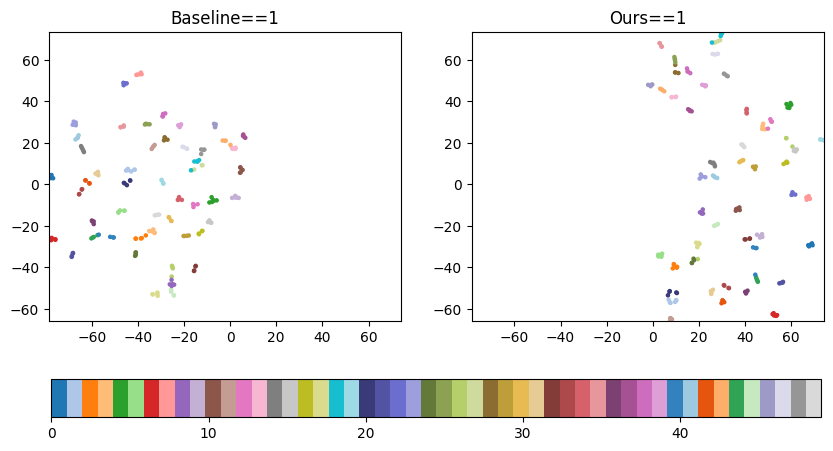

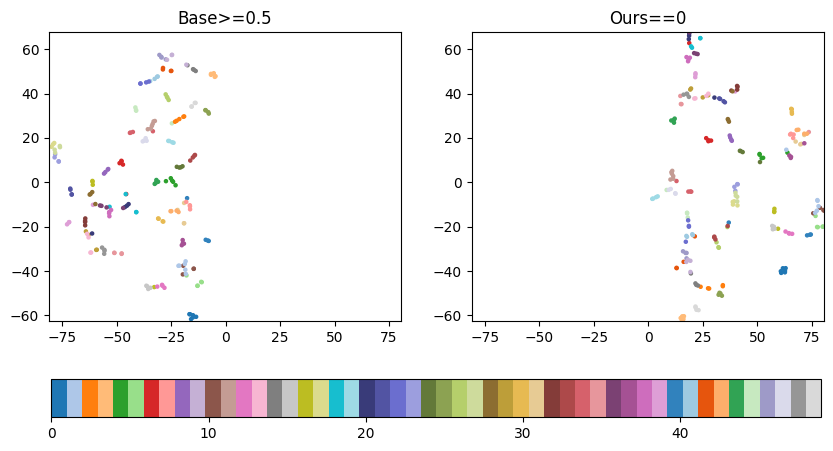

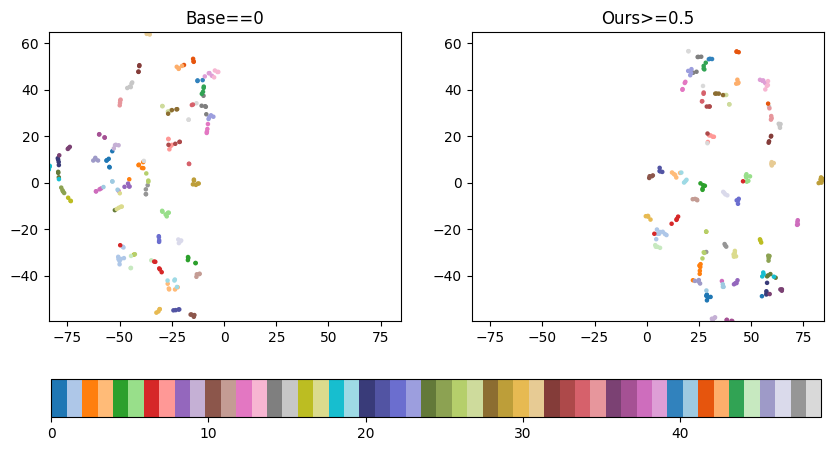

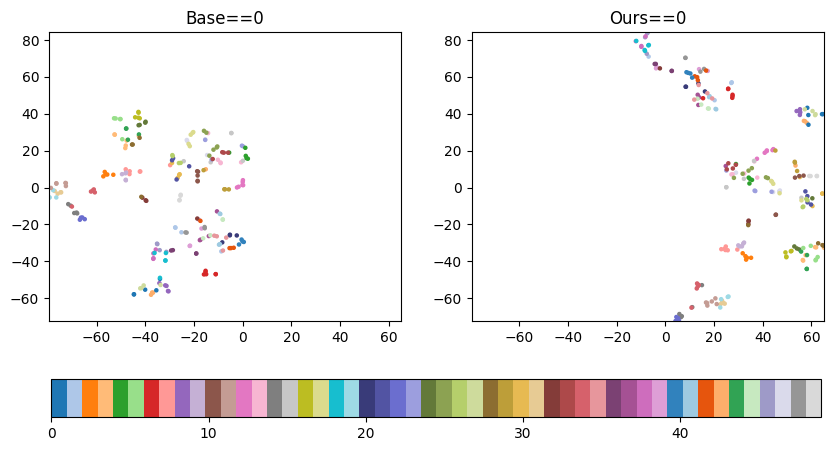

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from matplotlib.colors import ListedColormap

def plot_tsne(features_1, features_2, labels_1, labels_2, title_1, title_2):
    # Combine the features to get a common scope
    combined_features = np.vstack((features_1, features_2))
    
    # Fit t-SNE on the combined features
    tsne = TSNE(n_components=2, random_state=42, perplexity=4)
    tsne_results = tsne.fit_transform(combined_features)
    
    # Separate the t-SNE results
    tsne_results_1 = tsne_results[:len(features_1)]
    tsne_results_2 = tsne_results[len(features_1):]
    
    # Encode the labels as integers
    label_encoder = LabelEncoder()
    labels_1_encoded = label_encoder.fit_transform(labels_1)
    labels_2_encoded = label_encoder.transform(labels_2)

    # Create a custom colormap with 50 distinct colors
    colors = plt.cm.tab20(np.linspace(0, 1, 20)).tolist() + plt.cm.tab20b(np.linspace(0, 1, 20)).tolist() + plt.cm.tab20c(np.linspace(0, 1, 10)).tolist()
    custom_cmap = ListedColormap(colors[:50])

    # Plot the t-SNE results
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    scatter_1 = axes[0].scatter(tsne_results_1[:, 0], tsne_results_1[:, 1], c=labels_1_encoded, cmap=custom_cmap, s=5)
    scatter_2 = axes[1].scatter(tsne_results_2[:, 0], tsne_results_2[:, 1], c=labels_2_encoded, cmap=custom_cmap, s=5)
    
    axes[0].set_title(title_1)
    axes[1].set_title(title_2)

    # Calculate the mean and standard deviation of the t-SNE results
    x_mean, y_mean = np.mean(tsne_results, axis=0)
    x_std, y_std = np.std(tsne_results, axis=0)
    
    # Set the same limits for both subplots
    x_min, x_max = min(tsne_results[:, 0]), max(tsne_results[:, 0])
    y_min, y_max = min(tsne_results[:, 1]), max(tsne_results[:, 1])
    

    axes[0].set_xlim(x_min, x_max)
    axes[0].set_ylim(y_min, y_max)
    axes[1].set_xlim(x_min, x_max)
    axes[1].set_ylim(y_min, y_max)
    

    
    # Add a color bar
    plt.colorbar(scatter_1, ax=axes, orientation='horizontal', fraction=.1)
    
    plt.show()

# Plot t-SNE for each pair of feature lists
plot_tsne(feature_list_1_1, feature_list_1_2, label_list_1_1, label_list_1_2, 'Baseline==1', 'Ours==1')
plot_tsne(feature_list_2_1, feature_list_2_2, label_list_2_1, label_list_2_2, 'Base>=0.5', 'Ours==0')
plot_tsne(feature_list_3_1, feature_list_3_2, label_list_3_1, label_list_3_2, 'Base==0', 'Ours>=0.5')
plot_tsne(feature_list_4_1, feature_list_4_2, label_list_4_1, label_list_4_2, 'Base==0', 'Ours==0')


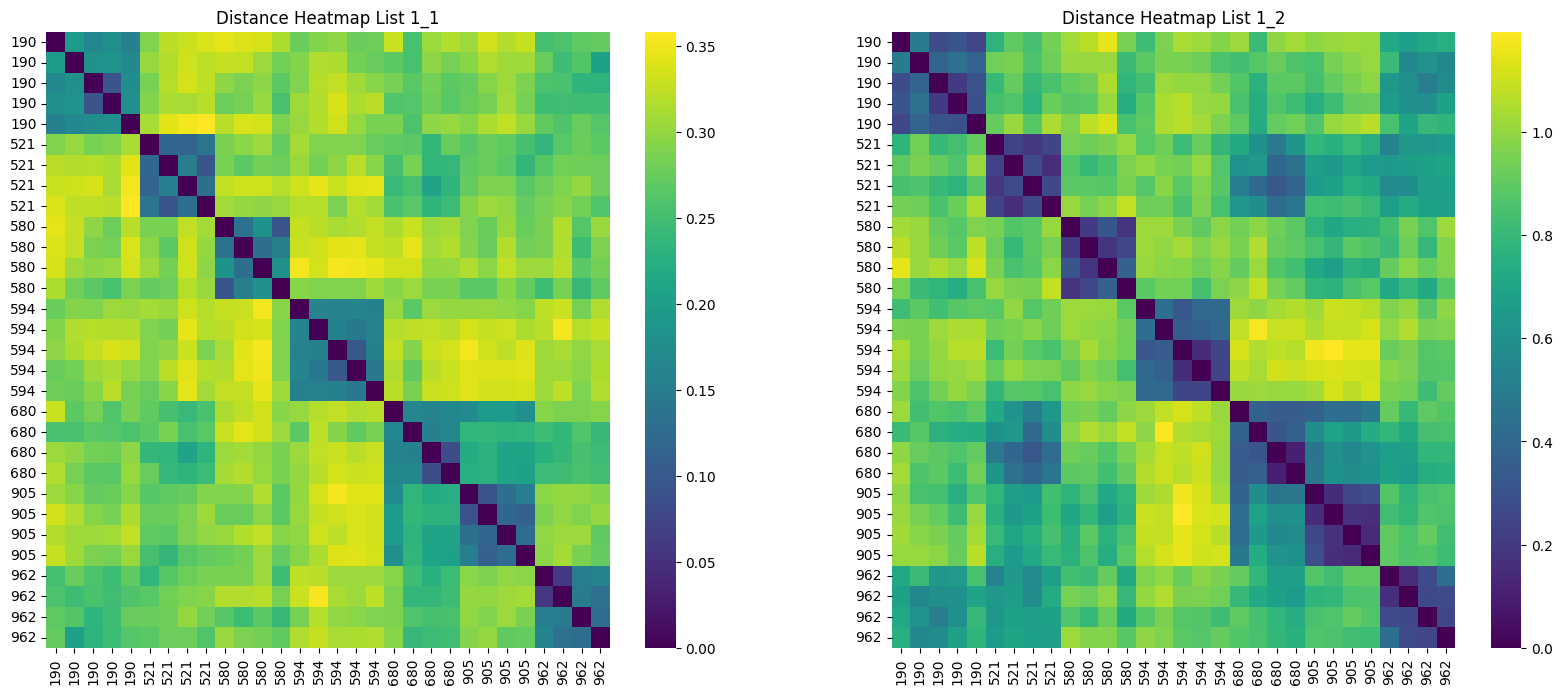

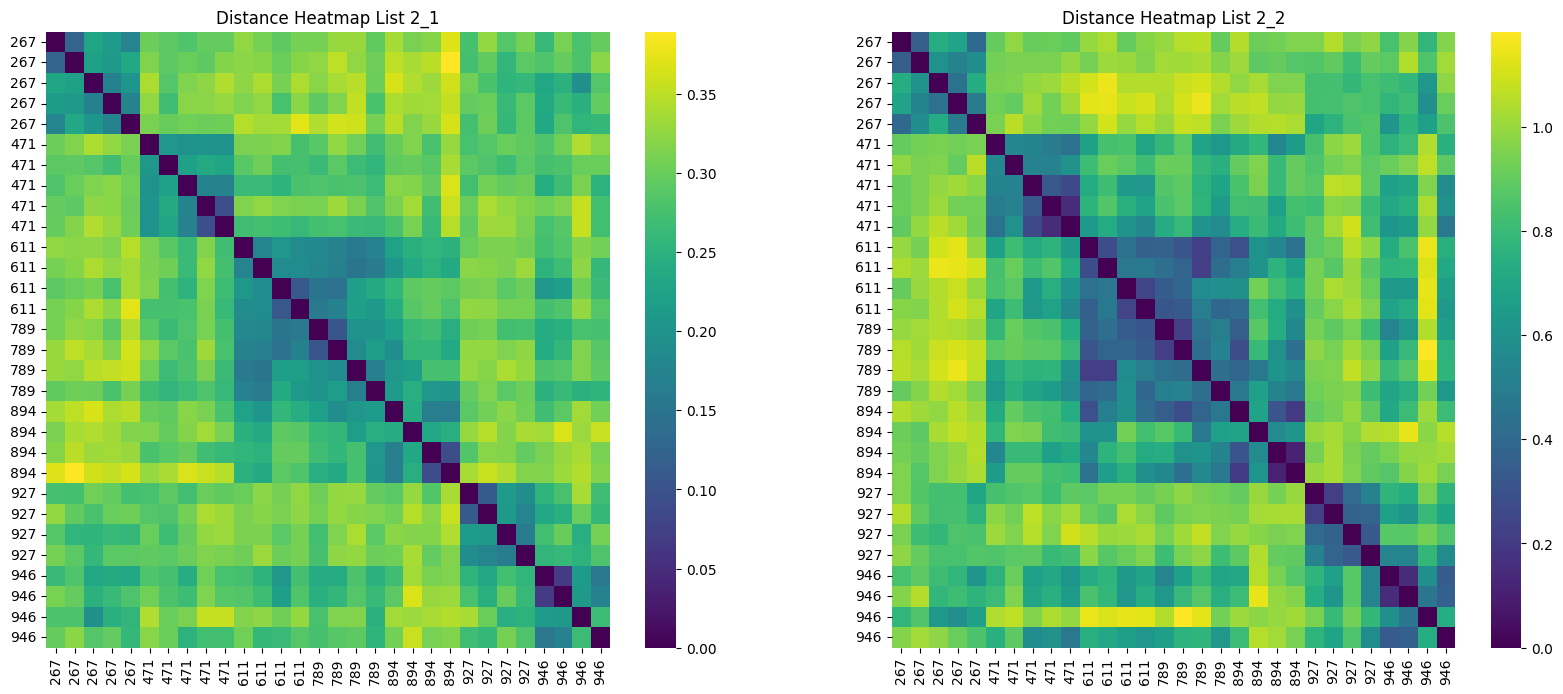

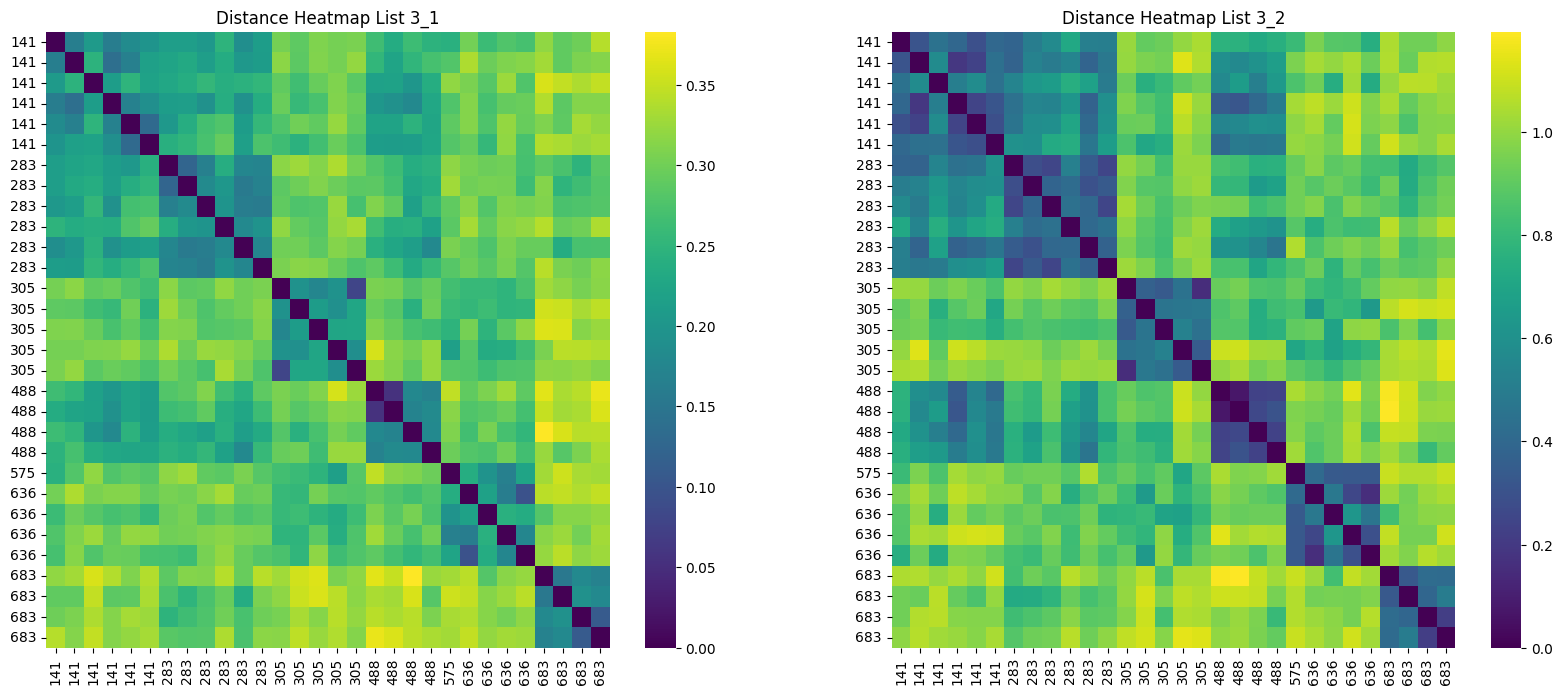

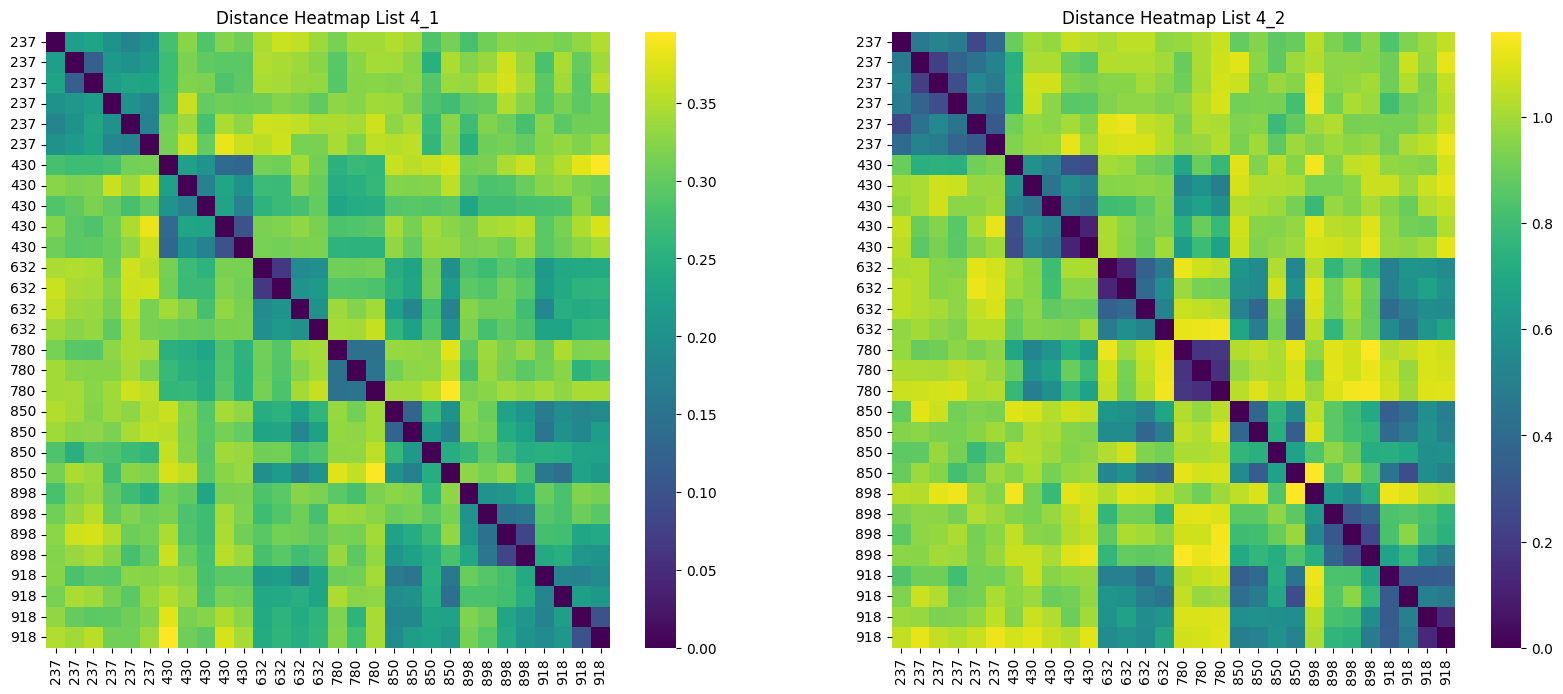

In [24]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

def align_features_by_labels(features, labels):
    # Sort features and labels based on the labels
    sorted_indices = np.argsort(labels)
    sorted_features = features[sorted_indices]
    sorted_labels = labels[sorted_indices]
    return sorted_features, sorted_labels


def plot_distance_heatmap(features_1, labels_1, features_2, labels_2, title_1, title_2):
    # Align features by labels
    aligned_features_1, sorted_labels_1 = align_features_by_labels(features_1, labels_1)
    aligned_features_2, sorted_labels_2 = align_features_by_labels(features_2, labels_2)
    
    # Ensure the labels are the same for both sets of features
    assert np.array_equal(sorted_labels_1, sorted_labels_2), "Labels do not match after sorting."
    
    # Compute pairwise distances
    distances_1 = squareform(pdist(aligned_features_1, metric='cosine'))
    distances_2 = squareform(pdist(aligned_features_2, metric='cosine'))
    
    # Plot heatmap for both sets of features
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    sns.heatmap(distances_1, ax=axes[0], cmap='viridis', cbar=True, xticklabels=sorted_labels_1, yticklabels=sorted_labels_1)
    sns.heatmap(distances_2, ax=axes[1], cmap='viridis', cbar=True, xticklabels=sorted_labels_1, yticklabels=sorted_labels_1)
    
    axes[0].set_title(title_1)
    axes[1].set_title(title_2)
    

    plt.show()

# Plot distance heatmap for each pair of feature lists
sample_num = 30
plot_distance_heatmap(feature_list_1_1[:sample_num], label_list_1_1[:sample_num], feature_list_1_2[:sample_num], label_list_1_2[:sample_num], 'Distance Heatmap List 1_1', 'Distance Heatmap List 1_2')
plot_distance_heatmap(feature_list_2_1[:sample_num], label_list_2_1[:sample_num], feature_list_2_2[:sample_num], label_list_2_2[:sample_num], 'Distance Heatmap List 2_1', 'Distance Heatmap List 2_2')
plot_distance_heatmap(feature_list_3_1[:sample_num], label_list_3_1[:sample_num], feature_list_3_2[:sample_num], label_list_3_2[:sample_num], 'Distance Heatmap List 3_1', 'Distance Heatmap List 3_2')
plot_distance_heatmap(feature_list_4_1[:sample_num], label_list_4_1[:sample_num], feature_list_4_2[:sample_num], label_list_4_2[:sample_num], 'Distance Heatmap List 4_1', 'Distance Heatmap List 4_2')


In [1]:
from PIL import Image, ImageDraw, ImageOps
import numpy as np
import random
import os

# Step 1: Create a custom shape mask
# Define the size of the canvas
canvas_size = (800, 600)  # Width x Height
mask = Image.new("L", canvas_size, 0)  # Create a blank mask with black background
draw = ImageDraw.Draw(mask)

# Draw a custom shape, here we're drawing a cow-like shape using an example polygon
# Replace this with the coordinates of the shape you want
cow_shape = [
    (150, 300), (200, 250), (300, 250), (350, 300),  # Top part
    (350, 400), (300, 450), (200, 450), (150, 400)   # Bottom part
]
draw.polygon(cow_shape, fill=255)  # Fill the shape with white color

# Optional: Visualize the mask (if needed)
# mask.show()

# Step 2: Load sample RGB images
sample_images_dir = "/home/stuyangz/Desktop/Zhengwei/github/datasets/TUBerlin/images/cow"  # Directory containing sample images
sample_images = [Image.open(os.path.join(sample_images_dir, f)).convert("RGBA") for f in os.listdir(sample_images_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

# Resize and randomize sample images
sample_images = [img.resize((int(img.width / 4), int(img.height / 4))) for img in sample_images]
random.shuffle(sample_images)

# Step 3: Create base image with transparent background
base_image = Image.new("RGBA", mask.size, (255, 255, 255, 0))

# Step 4: Place sample images randomly over the custom shape
mask_np = np.array(mask)
height, width = mask_np.shape

for img in sample_images:
    img_w, img_h = img.size

    # Try placing image in a random position within the shape defined by the mask
    for _ in range(100):  # Attempt 100 times to find a valid position
        x = random.randint(0, width - img_w)
        y = random.randint(0, height - img_h)

        # Check if the image fits within the mask shape
        img_mask_area = mask_np[y:y + img_h, x:x + img_w]
        if np.mean(img_mask_area) > 200:  # If mostly within the shape area
            base_image.paste(img, (x, y), img)  # Paste with transparency
            break

# Step 5: Apply the mask to the final image
final_image = Image.composite(base_image, Image.new("RGBA", mask.size, (255, 255, 255, 0)), mask)

# Step 6: Save or display the result
final_image.show()  # Display the image
# final_image.save("result.png")  # Save the result


/snap/core20/current/lib/x86_64-linux-gnu/libstdc++.so.6: version `GLIBCXX_3.4.29' not found (required by /lib/x86_64-linux-gnu/libproxy.so.1)
Failed to load module: /home/stuyangz/snap/code/common/.cache/gio-modules/libgiolibproxy.so
eog: symbol lookup error: /snap/core20/current/lib/x86_64-linux-gnu/libpthread.so.0: undefined symbol: __libc_pthread_init, version GLIBC_PRIVATE


In [13]:
# Step 1: Define the path for the mask and image folder
mask_path = "/home/stuyangz/Desktop/Zhengwei/github/datasets/TUBerlin/sketches/cow/4737.png"  # Path to the mask image (cow outline)
image_folder_path = "/home/stuyangz/Desktop/Zhengwei/github/datasets/TUBerlin/images/cow"  # Path to the folder containing sample images



In [18]:
python scripts/Image_Tester.py --images data/cow

python scripts/Mosaic_Creator.py --target data/cow.png --images data/cow/ --grid 100 100 --output data/Mosaic_cow.png

SyntaxError: invalid syntax (425130983.py, line 1)